Script Manipulator/Author: Hayden Mann

Original data retrival is based on: "Explore ICESat-2 ATL03 Photon Clouds with SlideRule", provided by Dr. Kelsey Bisson

Used to plot photon clouds for my presentation. Example:

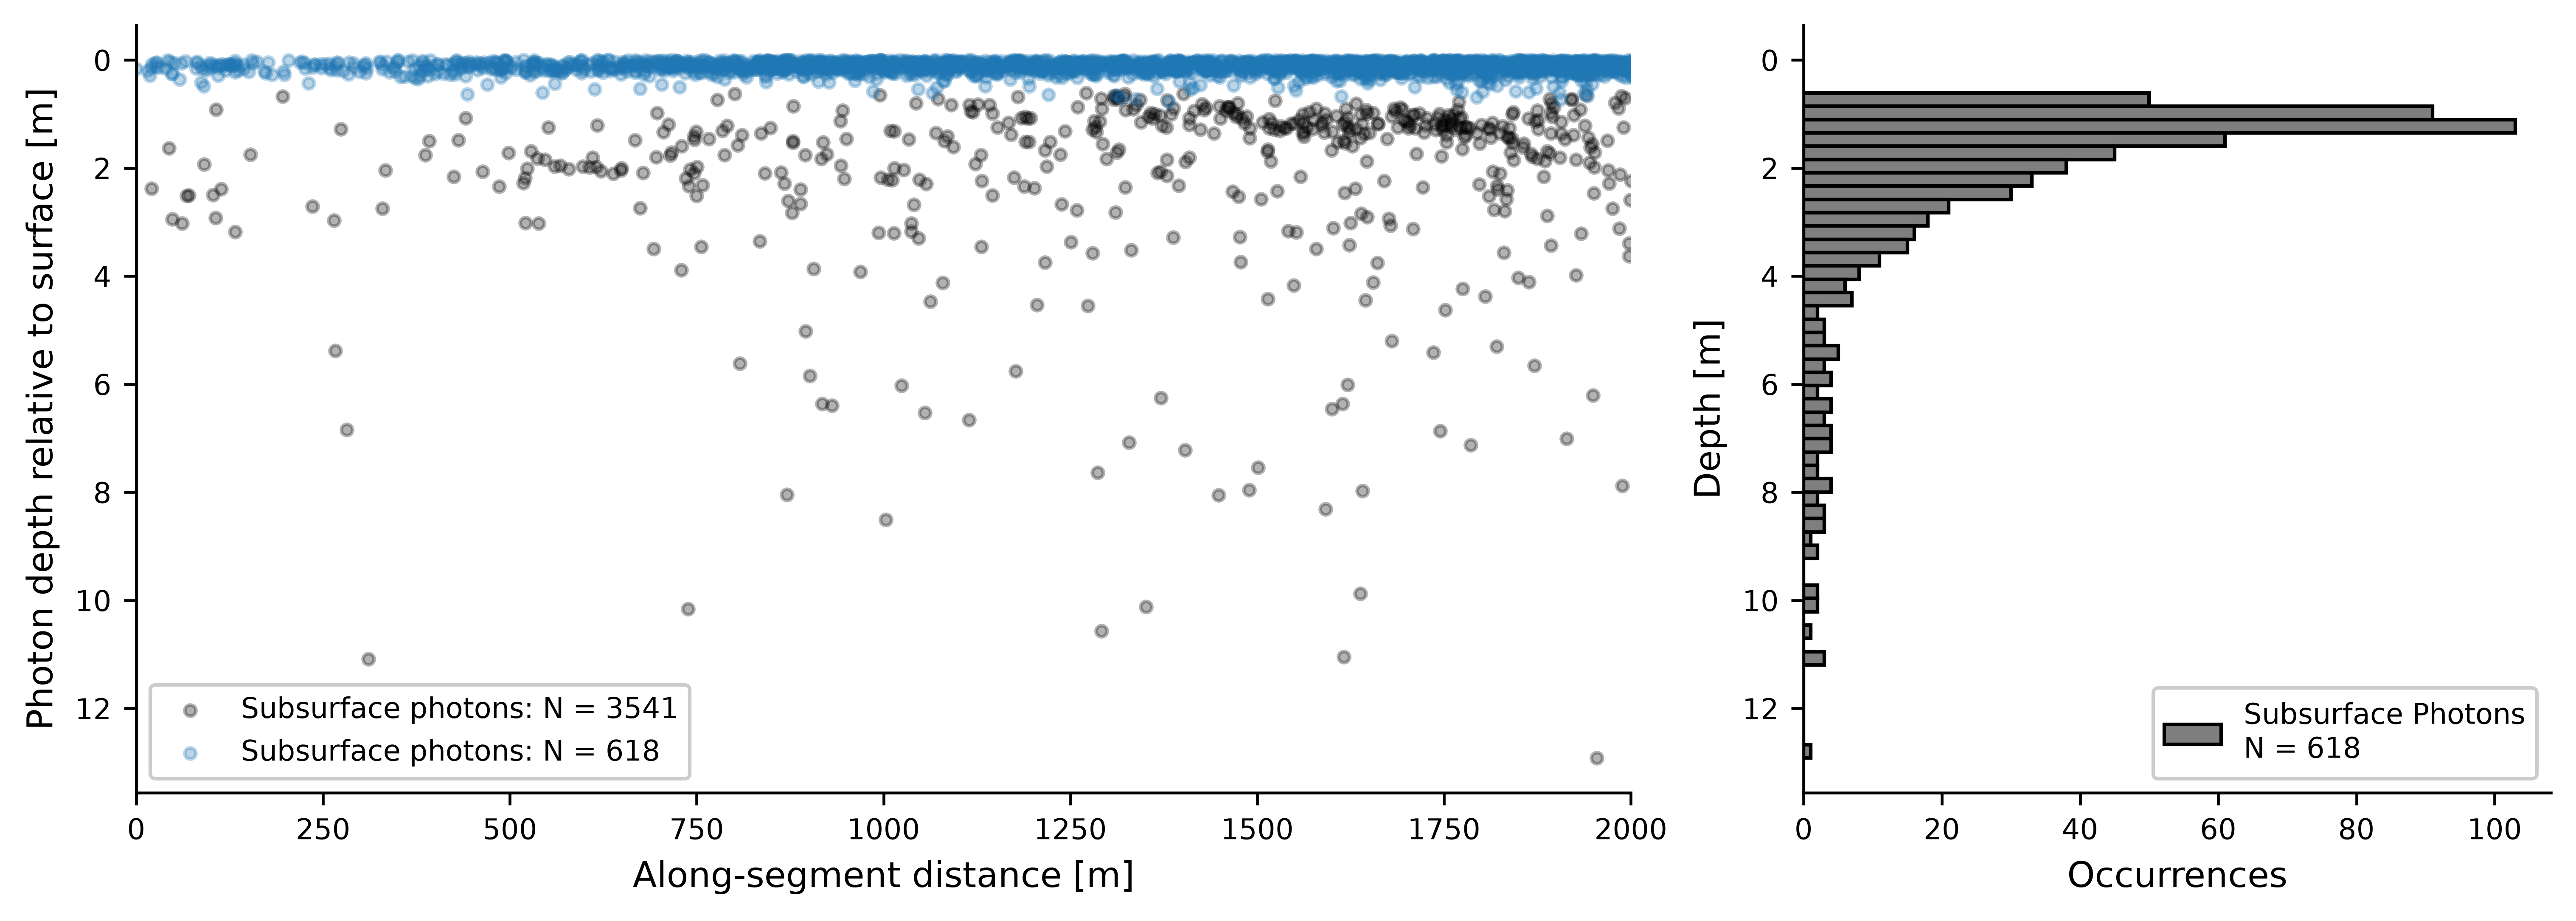

In [2]:
"""
Install and imports
"""
from pyproj import Transformer
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import StrMethodFormatter
import warnings
warnings.filterwarnings("ignore")
import contextily as cx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import rioxarray as rxr
import rasterio
from rasterio.features import rasterize


# Initialize sliderule
from sliderule import icesat2, sliderule
sliderule.init("slideruleearth.io", verbose=True)
pd.set_option("display.max_columns", 80)


In [3]:
"""
Configure Study Area + Photon-Input Parameters
"""

# North Carolina Core Sound
aoi = [
    {"lat": 34.86, "lon": -76.38},
    {"lat": 34.86, "lon": -76.16},
    {"lat": 35.04, "lon": -76.16},
    {"lat": 35.04, "lon": -76.38},
    {"lat": 34.86, "lon": -76.38},
]

resources = None

# Set photon-input parameters
    # Area of interest
    # start time
    # end time
    # confidence flag: here 0 means 'at least "atl03_background"'
    # srt: surface land type
    # photon field: count + solar elevation are ancillary columns. there are others I can add too
base_parms = {
    "poly": aoi,
    "t0": "2022-01-01T00:00:00Z",
    "t1": "2022-03-31T23:59:59Z",
    "cnf": 1,
    "srt": 1,
    "atl03_ph_fields": ["pce_mframe_cnt"],
    "atl03_geo_fields": ["solar_elevation"],
}

In [4]:
"""


Query ATL03 photon clouds with atl03x


"""

# Query:
photons = sliderule.run("atl03x", base_parms)
print(f"rows: {len(photons):,}")
print(f"columns: {len(photons.columns)}")
display(photons.head())


# add lon/lat columns
def add_lon_lat(gdf):
    """Return a copy with lon/lat columns derived from GeoDataFrame geometry."""
    out = gdf.copy()
    if "geometry" in out.columns:
        out["lon"] = out.geometry.x
        out["lat"] = out.geometry.y
    return out
photons_xy = add_lon_lat(photons)

request <AppServer.16340> retrieved 3 resources
Starting proxy for atl03x to process 3 resource(s) with 3 thread(s)
request <AppServer.17287> on ATL03_20220220220720_09261406_007_01.h5 generated dataframe [gt2l] with 0 rows and 13 columns
request <AppServer.16348> on ATL03_20220331081055_01261502_007_01.h5 generated dataframe [gt3r] with 1773 rows and 14 columns
request <AppServer.16348> on ATL03_20220331081055_01261502_007_01.h5 generated dataframe [gt3l] with 7492 rows and 14 columns
request <AppServer.16348> on ATL03_20220331081055_01261502_007_01.h5 generated dataframe [gt1r] with 1503 rows and 14 columns
request <AppServer.16348> on ATL03_20220331081055_01261502_007_01.h5 generated dataframe [gt1l] with 7592 rows and 14 columns
request <AppServer.16348> on ATL03_20220331081055_01261502_007_01.h5 generated dataframe [gt2l] with 5135 rows and 14 columns
request <AppServer.16348> on ATL03_20220331081055_01261502_007_01.h5 generated dataframe [gt2r] with 1266 rows and 14 columns
Succe

rows: 25,895
columns: 18


,region,gt,spacecraft_velocity,solar_elevation,rgt,ph_index,height,pce_mframe_cnt,spot,x_atc,y_atc,srcid,cycle,atl03_cnf,background_rate,segment_id,quality_ph,geometry
time_ns,,,,,,,,,,,,,,,,,,
2022-03-31 08:12:57.688175360,2,20,7114.483398,-31.798929,126,148230,-39.021473,36003991,2,3.879525e+06,3167.510986,4,15,4,9159.577148,193451,0,POINT (-76.24179 34.87146)
2022-03-31 08:12:57.688475392,2,20,7114.483398,-31.798929,126,148231,-39.028667,36003991,2,3.879527e+06,3167.502686,4,15,4,9159.577148,193451,0,POINT (-76.2418 34.87148)
2022-03-31 08:12:57.689475584,2,20,7114.483398,-31.798887,126,148232,-40.968025,36003991,2,3.879534e+06,3167.481934,4,15,4,9159.577148,193452,0,POINT (-76.2418 34.87154)
2022-03-31 08:12:57.691075328,2,20,7114.483398,-31.798887,126,148233,-39.689056,36003991,2,3.879546e+06,3167.444336,4,15,4,9159.577148,193452,0,POINT (-76.24182 34.87165)
2022-03-31 08:12:57.691275264,2,20,7114.483398,-31.798887,126,148234,-40.073902,36003991,2,3.879547e+06,3167.444336,4,15,4,9159.577148,193452,0,POINT (-76.24182 34.87166)


In [5]:
"""
Mask data to be only over water

atl03x land mask is not good enough. still has data over land.
"""

# Load land mask: https://www.arcgis.com/home/item.html?id=595533fecdb0472db4b4b8e3ca8d9e42#overview
land = gpd.read_file("ne_10m_land.shp")
land = land.to_crs(photons_xy.crs)


# define resolution (0.01° ~ 1km, adjust as needed)
res = 0.01

# Create land mask
minx, miny, maxx, maxy = -180, -90, 180, 90
width = int((maxx - minx) / res)
height = int((maxy - miny) / res)
transform = rasterio.transform.from_bounds(
    minx, miny, maxx, maxy, width, height
)
land_shapes = [(geom, 1) for geom in land.geometry]

# rasterize the land mask to make operation quicker!
land_raster = rasterize(
    land_shapes,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype="uint8"
)

# revtrieve geometry x and y's
xs = photons_xy.geometry.x.values
ys = photons_xy.geometry.y.values

# vectorize
col = ((xs - minx) / res).astype(np.int32)
row = ((maxy - ys) / res).astype(np.int32)

# mask (True or False)
valid = (
    (col >= 0) & (col < width) &
    (row >= 0) & (row < height)
)

# find amount on land
on_land = np.zeros(len(photons_xy), dtype=bool)

# validate by making sure both row and column are on land
on_land[valid] = land_raster[row[valid], col[valid]] == 1

# take the land mask and apply to the photons
photons_xy_ocean = photons_xy.loc[~on_land].copy()

In [6]:
"""
Detect water surface from the height histogram PER GT


Via Eidam et al: 2024. "For a lightweight ATL03-only first pass, estimate the water surface from the 
photon-height histogram. The densest height bin is treated as the candidate 
surface return, then `water_surface` keeps photons within an adaptive vertical 
window around that modal height. This is an exploratory detector: inspect the 
histogram diagnostics and tune the binning/window before using the result 
quantitatively. If the water-surface plot looks like only one or two points, 
first check the printed counts. A sparse or clustered-looking plot can 
happen even with thousands of selected photons when only a few ICESat-2 
pass/beam segments cross the small AOI and `x_atc` is plotted as an absolute 
along-track coordinate."


HAYDEN UPDATE: this should be done for each ground track, as SSH varies 
throughout the tracks, as different ground tracks are on different days.
"""

water_surface_list = []
below_surface_list = []
segmented_photons_list = []

# IMPORTANT
segment_length = 2000  

# separates individual ground tracks so that SSH isn't invalidated by tides, etc
for gt_value, gt_photons in photons_xy_ocean.groupby("gt"):

    # get rid of -infinity and +infinity height readings (measurement errors)
    height_values = gt_photons["height"].replace([np.inf, -np.inf], np.nan).dropna()

    # build histogram range + bins + counts + edges
    hist_range = tuple(height_values.quantile([0.01, 0.99]))
    hist_bins = int(np.clip(np.sqrt(len(height_values)), 40, 160))
    hist_counts, hist_edges = np.histogram(height_values, bins=hist_bins, range=hist_range)

    # water surface bin + bin centers
    water_surface_bin = int(np.argmax(hist_counts))
    water_surface_center = 0.5 * (hist_edges[water_surface_bin] + hist_edges[water_surface_bin + 1])

    # determine peak count in histogram + bin width
    hist_peak_count = int(hist_counts[water_surface_bin])
    hist_bin_width_m = float(hist_edges[1] - hist_edges[0])

    # use bin width to determine the 'half window' for the water surface
    water_surface_half_window_m = max(0.75, 1.5 * hist_bin_width_m)

    # Form a mask for the water surface
    water_surface_mask = gt_photons["height"].between(
        water_surface_center - water_surface_half_window_m,
        water_surface_center + water_surface_half_window_m,
    )

    # assign along-track segment IDs now, while we still have just this GT's
    # photons. Grouping by rgt+cycle (gt is already fixed by the outer loop)
    # handles repeat satellite passes over the same ground track.
    gt_photons = gt_photons.copy()
    gt_photons["custom_segment_id"] = (
        gt_photons.groupby(["rgt", "cycle"])["x_atc"]
        .transform(lambda x: ((x - x.min()) // segment_length).astype(int))
    )

    # mask for surface photons
    gt_photons["is_surface_photon"] = gt_photons["height"].between(
        water_surface_center - water_surface_half_window_m,
        water_surface_center + water_surface_half_window_m,
    )
    segmented_photons_list.append(gt_photons)

    # separate photons by height
    water_surface = gt_photons[water_surface_mask].copy()
    below_surface = gt_photons[gt_photons["height"] < water_surface_center - water_surface_half_window_m].copy()

    # determine water surface height resuidual
    water_surface["height_residual_m"] = water_surface["height"] - water_surface_center
    below_surface["height_residual_m"] = below_surface["height"] - water_surface_center


    # determine water surface fraction:
    water_surface_fraction = len(water_surface) / max(len(gt_photons), 1)

    water_surface_list.append(water_surface)
    below_surface_list.append(below_surface)

# combine all gts back together
water_surface = pd.concat(water_surface_list) if water_surface_list else pd.DataFrame()
below_surface = pd.concat(below_surface_list) if below_surface_list else pd.DataFrame()
photons_xy = pd.concat(segmented_photons_list)

In [7]:
# Limit for height at or below water surface
photons_xy = photons_xy[
    photons_xy['height'] < (water_surface_center + water_surface_half_window_m)
]
photons_xy['adj_height'] = photons_xy['height'] - water_surface_center
segment_counts = photons_xy["custom_segment_id"].value_counts()

# find most plentiful segments for exploration
print(segment_counts)

custom_segment_id
9     5983
8     4159
0     3622
7     3306
1     3162
2     1671
6     1256
4      575
5      438
3      182
10     139
Name: count, dtype: int64


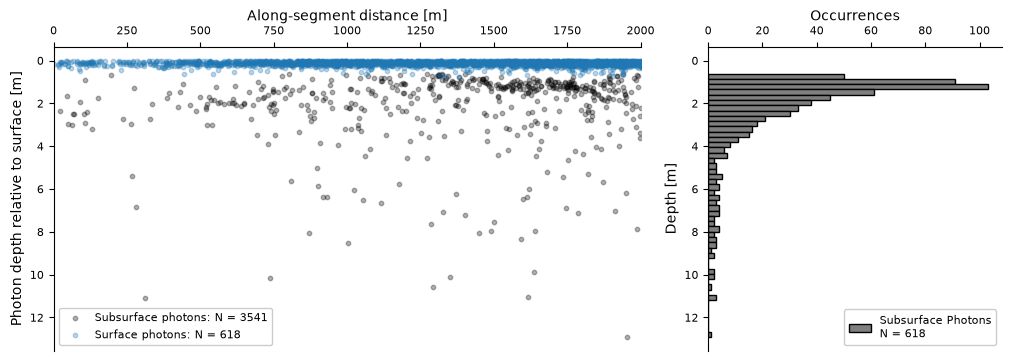

In [23]:
# Selected a segment with interesting depth profile for this plot
photon_seg = photons_xy[photons_xy["custom_segment_id"] == 8].copy()
photon_seg['adj_depth'] = np.abs(photon_seg['adj_height'])

surface = photon_seg[photon_seg["is_surface_photon"]]
subsurface = photon_seg[~photon_seg["is_surface_photon"]]


# relative along-track distance
photon_seg["x_segment"] = photon_seg["x_atc"] - photon_seg["x_atc"].min()
surface["x_segment"] = surface["x_atc"] - photon_seg["x_atc"].min()
subsurface["x_segment"] = subsurface["x_atc"] - photon_seg["x_atc"].min()


# Instantiate plots
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(10, 3.5),
    constrained_layout=True,
    gridspec_kw={'width_ratios': [4, 2]}
)

# Parameters to be kept consistent across all plots
plt.rcParams.update({
    "font.family": "DejaVu Sans", # or Arial
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

surface_color = "#1f77b4"
subsurface_color = "#7f7f7f"

# Scatter plot
ax1.scatter(
    subsurface["x_segment"],
    subsurface["adj_depth"],
    s=10,
    c= "black",
    label="Subsurface photons: N = " + str(len(surface['adj_depth'])),
    alpha=0.3
)
ax1.scatter(
    surface["x_segment"],
    surface["adj_depth"],
    s=10,
    c=surface_color,
    label="Surface photons: N = " + str(len(subsurface['adj_depth'])),
    alpha=0.3
)

ax1.set_xlim(0, 2000)
ax1.set_xlabel("Along-segment distance [m]")
ax1.set_ylabel("Photon depth relative to surface [m]")
ax1.legend(
    framealpha=1,
    loc="lower left",
    fontsize=8
)
# ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.invert_yaxis()



# Histogram

ax2.hist(subsurface['adj_depth'], bins=50,
        facecolor="#7f7f7f", edgecolor='black', orientation='horizontal', label=("Subsurface Photons\nN = " + str(len(subsurface['adj_height']))))



ax2.set_xlabel('Occurrences') 
ax2.set_ylabel('Depth [m]') 
ax2.set_ylim(ax1.get_ylim())
# ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(
    framealpha=1,
    loc="lower right",
    fontsize=8
)


ax1.xaxis.set_ticks_position('top')
ax1.xaxis.set_label_position('top')
ax1.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False)

ax2.xaxis.set_ticks_position('top')
ax2.xaxis.set_label_position('top')
ax2.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False)

ax1.spines['bottom'].set_visible(False)
ax2.spines['bottom'].set_visible(False)


plt.savefig(
    "FINAL_FIGS/photon_cloud.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()